# Experimento Federado Semântico IoT/GenAI 6G

Neste laboratório em Jupyter Notebook, simulamos uma arquitetura de comunicação Edge via redes semânticas.

## 📖 Sumário Executivo: A Bússola do Experimento

Para fins de validação acadêmica e facilidade de reprodução, este Jupyter Notebook atua como o **Painel de Controle Central** de toda a simulação semântica 6G. Cada módulo possui um propósito estrito e eles **devem ser executados na ordem numérica apresentada**:

> [!NOTE]  
> **Regra de Ouro:** Não avance para um módulo subsequente enquanto a barra de progresso (Loader) da célula atual não indicar `[100% concluído]` ou o aviso de `MERGULHO CONCLUÍDO`.

<br>

| Módulo Estrutural | Descrição Funcional Acadêmica | Obrigatório | Células |
| :--- | :--- | :---: | :---: |
| 📘 **Módulo 1: A Fundação Edge** | Define os parâmetros globais (`DATASET`, `MODEL`), valida a comunicação com os contêineres Docker e **baixa os datasets** (MNIST, Fashion‑MNIST, CIFAR‑10). A **Célula 3 é obrigatória** — sem os dados no volume o treinamento da Célula 4 falha. | ✅ Sim | `1, 2, 3` |
| 🧠 **Módulo 2: O Cérebro Semântico** | Núcleo de aprendizagem federada. A **Célula 4** treina o Autoencoder (canal semântico) via FedAvg e **salva os pesos**. A **Célula 5** treina o Classificador Juiz com esses pesos. Ambos os modelos são reutilizados pelas Células 6 e 7 — **não são retreinados**. | ✅ Sim | `4 e 5` |
| 🔬 **Módulo 3: O Laboratório Visual** | *(Recomendado antes do Paper)* Auditoria ocular. Renderiza mosaicos de amostras reais: original × recebido com ruído × reconstruído pelo Decoder. Usa os pesos fixos da Célula 4. Ideal para validar qualitativamente o canal e capturar figuras para o artigo. | ⚡ Opcional | `6` |
| 🏭 **Módulo 4: A Fábrica de Trade-off** | O Benchmark do *Paper*. **Não retreina nenhum modelo.** Usa os pesos salvos pelas Células 4 e 5 e varia apenas a dimensão latente `[16, 32, 64, 128, 256 bytes]` no canal para mapear a Curva de Trade-off (Compressão × Queda Semântica). Exporta **CSV + 2 gráficos** prontos para o LaTeX. | ✅ Sim | `7` |

## 📘 Módulo 1: A Fundação Edge (Setup do Testbed)
Aqui instanciamos o cérebro PyTorch e subimos os contêineres Docker para emular nós GenAI independentes da nuvem.

In [7]:
# Célula 1 — Setup
import json, subprocess, time
from pathlib import Path
import requests

try:
    import pandas as pd; HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False; print('[aviso] pandas ausente')

try:
    import matplotlib.pyplot as plt, matplotlib, numpy as np
    HAS_MATPLOTLIB = True
    print(f'[ok] matplotlib {matplotlib.__version__}')
except Exception:
    HAS_MATPLOTLIB = False; print('[aviso] matplotlib ausente')

ML_SERVICE  = 'http://localhost:8000'
FL_SERVER   = 'http://localhost:8100'
SHARED_ROOT = Path('shared_data')
RESULTS_DIR = SHARED_ROOT / 'resultados' / 'notebook_monitor'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════
#  CONFIGURAÇÃO CENTRAL
# ════════════════════════════════════════════════════════
DATASET  = 'cifar10'    # mnist | fashion | cifar10
MODEL    = 'cnn_vae'
CLIENTS  = 3
ROUNDS   = 3
EPOCHS   = 3
SEED     = 42
AWGN_CFG = {'enabled': True, 'snr_db': 15}
MASK_CFG = {'enabled': True, 'drop_rate': 0.1, 'fill_value': 0.0}
LATENT_DIM = 256   # Utilizado nas etapas Manuais (Células 4 e 5)

# ════════════════════════════════════════════════════════

_BYTES_BRUTOS  = {'mnist': 3136, 'fashion': 3136, 'cifar10': 12288}
_BYTES_LATENTE = 256*4 
print(f'[ok] {DATASET} | {MODEL} | {CLIENTS} clientes | {ROUNDS} rounds')
print(f'     Reducao teor.: {(1 - _BYTES_LATENTE/_BYTES_BRUTOS[DATASET])*100:.1f}%')

[ok] matplotlib 3.10.8
[ok] cifar10 | cnn_vae | 3 clientes | 3 rounds
     Reducao teor.: 91.7%


In [8]:
# Célula 2 — Subir containers Docker
import json, shutil, subprocess, time
from pathlib import Path
import requests

SHARED_ROOT = Path('shared_data')
for pasta in [SHARED_ROOT / 'fl-weights', SHARED_ROOT / 'resultados']:
    if pasta.exists(): shutil.rmtree(pasta); print(f'[setup] limpo: {pasta}')
for d in [SHARED_ROOT/'ml-data'/'datasets', SHARED_ROOT/'ml-data'/'runs',
          SHARED_ROOT/'ml-data'/'logs', SHARED_ROOT/'fl-weights',
          SHARED_ROOT/'resultados'/'notebook_monitor']:
    d.mkdir(parents=True, exist_ok=True)

print('[setup] Subindo containers...')
res = subprocess.run(['docker', 'compose', 'up', '-d', '--build'], capture_output=True, text=True)
if res.returncode != 0: print('ERRO:', res.stderr[-2000:]); raise RuntimeError('docker compose falhou')
print(f'[setup] OK')
time.sleep(8)
for nome, porta in [('ml-service', 8000), ('fl-server', 8100)]:
    ok = False
    for _ in range(20):
        try:
            if requests.get(f'http://localhost:{porta}/health', timeout=3).ok: ok = True; break
        except: pass
        time.sleep(2)
    print(f'[setup] {nome}: {"OK" if ok else "NAO RESPONDEU"}')
    if not ok: raise RuntimeError(f'{nome} nao respondeu')
print('[setup] Todos os containers prontos!')

[setup] limpo: shared_data\fl-weights
[setup] limpo: shared_data\resultados
[setup] Subindo containers...
[setup] OK
[setup] ml-service: OK
[setup] fl-server: OK
[setup] Todos os containers prontos!


In [9]:
# Célula 3 — Baixar datasets dentro do container
import time, requests
ML_SERVICE = 'http://localhost:8000'
DATASETS_A_BAIXAR = ['mnist', 'fashion', 'cifar10']
print(f'[datasets] Solicitando: {DATASETS_A_BAIXAR}')
r = requests.post(f'{ML_SERVICE}/data/prepare', json={'datasets': DATASETS_A_BAIXAR}, timeout=10)
print(f'[datasets] {r.json()}')
t0, ultimo = time.time(), None
while True:
    try: st = requests.get(f'{ML_SERVICE}/data/prepare/status', timeout=5).json()
    except: time.sleep(3); continue
    if st.get('current') != ultimo and st.get('current'):
        print(f'[datasets] Baixando {st["current"].upper()}...'); ultimo = st['current']
    if not st.get('running'):
        print(f'[datasets] Prontos: {st.get("done")}'); break
    if time.time()-t0 > 600: print('TIMEOUT'); break
    time.sleep(3)
print('[datasets] Pronto!')

[datasets] Solicitando: ['mnist', 'fashion', 'cifar10']
[datasets] {'status': 'started', 'datasets': ['mnist', 'fashion', 'cifar10']}
[datasets] Baixando MNIST...
[datasets] Baixando CIFAR10...
[datasets] Prontos: ['mnist', 'fashion', 'cifar10']
[datasets] Pronto!


---
## 🧠 Módulo 2: Os Dois Cérebros Semânticos (Treinamento Paralelo)

*A Comunicação Semântica exige dois agentes: A Antena Compressora (O Encoder Rádio Base) e o Sensor Decodificador (O Juiz Classificador).* Nossa inteligência artificial deve agora construir as lógicas matemáticas de transmissão para ruídos complexos.


In [ ]:
"""
Célula 4 (Arquitetura Final Unificada)
======================================================
Para cada latent_dim em [16, 32, 64, 128, 256]:
  1. Dispara treinamento do Autoencoder via FedAvg (fl-server/fl-clients)
  2. Monitora progresso em tempo real (logs + status do fl-server)
  3. Aguarda conclusão antes de passar para o próximo dim

Os pesos são salvos automaticamente pelo fl-server como:
  /ml-data/weights/{DATASET}_{MODEL}_d{DIM}.pth

"""

import json
import time
from pathlib import Path

import requests

# ─── Configuração ────────────────────────────────────────────────────────────
ML_SERVICE  = "http://localhost:8000"
FL_SERVER   = "http://localhost:8100"
LOGS_DIR    = Path("shared_data/ml-data/logs")

DATASET     = "cifar10"   # mnist | fashion | cifar10
MODEL       = "cnn_vae"
CLIENTS     = 3
ROUNDS      = 3
EPOCHS      = 3
SEED        = 42
AWGN_CFG    = {"enabled": True, "snr_db": 15}
MASK_CFG    = {"enabled": True, "drop_rate": 0.1, "fill_value": 0.0}

# A dimensão central a ser usada nas células individuais (Células 5 e 6)
# Aqui treinamos TODAS as dimensões.
LATENT_DIMS = [256]

TIMEOUT     = 7200  # 2h min por dim
MAX_FALHAS  = 10
KEYWORDS    = (
    "round", "ep ", "epoch", "loss", "fedavg", "submit",
    "shard", "done", "error", "aggregat", "client", "training",
    "batch", "lr=",
)

# ─── Helpers ─────────────────────────────────────────────────────────────────

def _novos(path: Path, offset: int) -> tuple[str, int]:
    if not path.exists():
        return "", offset
    try:
        t = path.read_text(encoding="utf-8", errors="replace")
    except Exception:
        return "", offset
    return t[offset:], len(t)


def _barra(atual: int, total: int, w: int = 30) -> str:
    p = min(atual / max(total, 1), 1.0)
    c = int(p * w)
    return "█" * c + "░" * (w - c)


def _treinar_dim(latent_dim: int) -> dict:
    """Dispara treinamento para um latent_dim e monitora até conclusão."""
    print(f"\n{'='*65}")
    print(f"  ▶ TREINANDO  latent_dim={latent_dim}  [{DATASET}/{MODEL}]")
    print(f"{'='*65}")

    payload = {
        "dataset": DATASET,
        "model": MODEL,
        "clients": CLIENTS,
        "epochs": EPOCHS,
        "latent_dim": latent_dim,
        "rounds": ROUNDS,
        "seed": SEED,
        "compression_mode": "baseline",
        "compression_bits": 8,
        "awgn": AWGN_CFG,
        "masking": MASK_CFG,
    }

    st = requests.post(f"{ML_SERVICE}/training/start", json=payload, timeout=15).json()
    print(f"  [treino] → {st.get('status')}")
    time.sleep(5)

    offs = {"server": 0}
    for i in range(1, CLIENTS + 1):
        offs[f"client-{i}"] = 0

    t0 = time.time()
    falhas = 0
    ur, ue = -1, ""

    while True:
        elapsed = int(time.time() - t0)
        if elapsed > TIMEOUT:
            print("  [TIMEOUT] tempo estourado")
            break

        try:
            ml = requests.get(f"{ML_SERVICE}/training/status", timeout=5).json()
            falhas = 0
        except Exception:
            falhas += 1
            if falhas >= MAX_FALHAS:
                print("  [ERRO] containers não respondem")
                break
            time.sleep(3)
            continue

        try:
            s     = requests.get(f"{FL_SERVER}/training/status", timeout=5).json()
            estado = s.get("state", "?")
            rnd    = int(s.get("current_round") or 0)
            tot    = int(s.get("total_rounds") or ROUNDS)
            sub    = s.get("submitted_clients", [])
            exp    = int(s.get("expected_clients") or CLIENTS)
            hist   = s.get("history", [])
        except Exception:
            estado, rnd, tot, sub, exp, hist = "?", 0, ROUNDS, [], CLIENTS, []

        if rnd != ur or estado != ue:
            barra = _barra(rnd, tot)
            pct   = rnd / max(tot, 1) * 100
            sub_s = ", ".join(str(x) for x in sorted(sub)) if sub else "nenhum"
            print(f"  +-- ROUND [{barra}] {rnd}/{tot} ({pct:.0f}%) [{elapsed}s] {estado}")
            print(f"  |   Submetidos: [{sub_s}] / {exp}")
            if hist:
                h = hist[-1]
                print(f"  |   Round {h.get('epoch', '?'):>2}: loss={h.get('loss', 0):.5f}")
            print(f"  +{'-'*62}")
            ur, ue = rnd, estado

        for i in range(1, CLIENTS + 1):
            k = f"client-{i}"
            nv, offs[k] = _novos(LOGS_DIR / f"training_{k}.log", offs[k])
            for ln in nv.strip().split("\n"):
                if ln.strip() and any(w in ln.lower() for w in KEYWORDS):
                    print(f"  [client-{i}] {ln.strip()}")

        nv_s, offs["server"] = _novos(LOGS_DIR / "training_server.log", offs["server"])
        for ln in nv_s.strip().split("\n"):
            if ln.strip() and any(w in ln.lower() for w in KEYWORDS):
                print(f"  [server  ] {ln.strip()}")

        if not ml.get("running", False):
            try:
                res     = requests.get(f"{ML_SERVICE}/results/latest", timeout=10).json()
                fl      = res.get("final_loss", "?")
                print(f"  {'='*62}")
                print(f"  ✓ latent_dim={latent_dim} CONCLUÍDO em {elapsed//60}min {elapsed%60}s | loss={fl}")
                print(f"  {'='*62}")
                return {"latent_dim": latent_dim, "final_loss": fl, "elapsed": elapsed}
            except Exception as exc:
                print(f"  [erro ao ler resultado] {exc}")
            break

        time.sleep(4)

    return {"latent_dim": latent_dim, "final_loss": "?", "elapsed": int(time.time() - t0)}


# ─── Loop principal ───────────────────────────────────────────────────────────
print("╔" + "═"*67 + "╗")
print("║  CÉLULA 4 — AUTOENCODER × LATENT_DIM (Arquitetura Unificada)     ║")
print("╚" + "═"*67 + "╝")
print(f"  Dataset: {DATASET}  |  Modelo: {MODEL}  |  Dims: {LATENT_DIMS}")
print()

resultados_c4 = []
for dim in LATENT_DIMS:
    r = _treinar_dim(dim)
    resultados_c4.append(r)
    # Pequena pausa entre treinos para o servidor se estabilizar
    time.sleep(3)

print("\n" + "═"*68)
print("  RESUMO — CÉLULA 4")
print("═"*68)
print(f"  {'latent_dim':>12} | {'final_loss':>12} | {'tempo':>8}")
print(f"  {'-'*12}-+-{'-'*12}-+-{'-'*8}")
for r in resultados_c4:
    t = r['elapsed']
    print(f"  {r['latent_dim']:>12} | {str(r['final_loss']):>12} | {t//60}m{t%60:02d}s")

print("\n✓ Célula 4 concluída! Execute celula 5 (Classificadores).")

# Persiste resultado para as próximas células
Path("shared_data/resultados/notebook_monitor").mkdir(parents=True, exist_ok=True)
Path("shared_data/resultados/notebook_monitor/cell4_resultado.json").write_text(
    json.dumps({
        "dataset": DATASET, "model": MODEL,
        "latent_dims": LATENT_DIMS, "resultados": resultados_c4,
    }, indent=2),
    encoding="utf-8",
)


╔═══════════════════════════════════════════════════════════════════╗
║  CÉLULA 4 — AUTOENCODER × LATENT_DIM (Arquitetura Unificada)     ║
╚═══════════════════════════════════════════════════════════════════╝
  Dataset: cifar10  |  Modelo: cnn_vae  |  Dims: [256]


  ▶ TREINANDO  latent_dim=256  [cifar10/cnn_vae]
  [treino] → started
  +-- ROUND [██████████░░░░░░░░░░░░░░░░░░░░] 1/3 (33%) [0s] round_active
  |   Submetidos: [nenhum] / 3
  +--------------------------------------------------------------
  [client-1] [23:45:49] [client-1] Client 1/3 waiting 0s before start
  [client-1] [23:45:49] [client-1] Waiting for fl-server at http://fl-server:8100...
  [client-1] [23:45:49] [client-1] Connected to fl-server
  [client-1] [23:45:49] [client-1] Device=cpu; polling server
  [client-1] [23:47:07] [client-1] Loaded shard [0,16666) size=16666
  [client-1] [23:47:08] [client-1] [round 1 ep 1/3] batch 0/131 loss=0.06296
  [client-1] [23:47:55] [client-1] [round 1 ep 1/3] batch 60/131 loss=0.0

190

In [10]:
"""
Célula 5 (Arquitetura Final Unificada)
======================================================
Para cada latent_dim em [16, 32, 64, 128, 256]:
  1. Carrega encoder_{dim}.pth (treinado na Célula 4)
  2. Treina Classificador Juiz sobre as reconstruções DESSE encoder
  3. Salva classifier_{dim}.pth

Raciocínio: o Classificador deve ser calibrado para o nível de qualidade
da reconstrução do encoder que ele vai julgar.  Um Juiz treinado em
latent=32 estaria enviesado se aplicado às reconstruções borradas de latent=16.

"""

import json
import time
from pathlib import Path

import requests

# ─── Configuração ────────────────────────────────────────────────────────────
ML_SERVICE  = "http://localhost:8000"
DATASET     = "cifar10"   # mnist | fashion | cifar10
MODEL       = "cnn_vae"
LATENT_DIMS = [256]

# Configurações de treino do classificador por dataset
CONFIG_TREINO = {
    "mnist":   {"epochs": 4,  "samples": 5000},
    "fashion": {"epochs": 8,  "samples": 12000},
    "cifar10": {"epochs": 15, "samples": 25000},
}

# Endpoint legado que a Célula 5 usa
TRAIN_QUICK_URL = f"{ML_SERVICE}/classifier/train-quick"
STATUS_URL      = f"{ML_SERVICE}/classifier/train-quick/status"

# ─── Helpers ─────────────────────────────────────────────────────────────────

def _treinar_classificador(latent_dim: int, cfg: dict) -> dict:
    """Treina um classificador calibrado para latent_dim e aguarda conclusão."""
    print(f"\n  ▶ [{DATASET.upper()} / latent_dim={latent_dim}]  Acordando API...")
    print(f"    [PARÂMETROS] → {cfg['epochs']} épocas | {cfg['samples']} imagens | dim={latent_dim}")

    payload = {
        "dataset":    DATASET,
        "epochs":     cfg["epochs"],
        "samples":    cfg["samples"],
        "seed":       42,
        "latent_dim": latent_dim,   # chave fundamental: informa ao backend qual encoder usar
    }

    try:
        start = requests.post(TRAIN_QUICK_URL, json=payload, timeout=10)
    except Exception as exc:
        print(f"    [FALHA HTTP] {exc}")
        return {"latent_dim": latent_dim, "accuracy": None, "error": str(exc)}

    if start.status_code not in (200, 202):
        print(f"    [ERRO API] status={start.status_code}: {start.text[:200]}")
        return {"latent_dim": latent_dim, "accuracy": None, "error": start.text[:200]}

    print(f"    [STATUS] Pedido aceito — monitorando...")
    t0 = time.time()
    ultimo_ep = -1

    while True:
        try:
            st = requests.get(STATUS_URL, timeout=5).json()
        except Exception:
            time.sleep(3)
            continue

        ep      = st.get("epoch", 0)
        tot     = st.get("total_epochs", cfg["epochs"])
        elapsed = int(time.time() - t0)

        if ep != ultimo_ep and ep > 0:
            print(f"    ✓ Epoch {ep}/{tot} ({ep/max(tot,1)*100:.0f}%) [{elapsed}s]")
            ultimo_ep = ep

        if not st.get("running"):
            if st.get("error"):
                print(f"    [ERRO TREINO] {st['error']}")
                return {"latent_dim": latent_dim, "accuracy": None, "error": st["error"]}
            elif st.get("done"):
                acc = st.get("accuracy", 0.0)
                print(f"    ★ CONCLUÍDO em {elapsed}s | Acurácia: {acc*100:.1f}%")
                return {"latent_dim": latent_dim, "accuracy": acc, "elapsed": elapsed}
            else:
                print("    [AVISO] Status parou inesperadamente — verifique logs do docker.")
                return {"latent_dim": latent_dim, "accuracy": None, "error": "stopped unexpectedly"}

        if elapsed > 7200:
            print("    [TIMEOUT] 2h estouradas.")
            return {"latent_dim": latent_dim, "accuracy": None, "error": "timeout"}

        time.sleep(4)


# ─── Loop principal ───────────────────────────────────────────────────────────
print("╔" + "═"*67 + "╗")
print("║  CÉLULA 5 — CLASSIFICADOR JUIZ × LATENT_DIM (Calibrado)          ║")
print("╚" + "═"*67 + "╝")
print(f"  Dataset: {DATASET}  |  Dims: {LATENT_DIMS}")
print()

DS_safe = DATASET.lower().strip()
cfg     = CONFIG_TREINO.get(DS_safe, {"epochs": 5, "samples": 3000})

print("=" * 68)
print(f" Escola de Juízes Semânticos — {DS_safe.upper()}")
print("=" * 68)
print(f" Fila: {LATENT_DIMS}\n")

resultados_c5 = []
for dim in LATENT_DIMS:
    r = _treinar_classificador(dim, cfg)
    resultados_c5.append(r)
    time.sleep(2)

print("\n" + "═"*68)
print("  RESUMO — CÉLULA 5")
print("═"*68)
print(f"  {'latent_dim':>12} | {'acurácia':>10} | {'tempo':>8}")
print(f"  {'-'*12}-+-{'-'*10}-+-{'-'*8}")
for r in resultados_c5:
    acc  = f"{r['accuracy']*100:.1f}%" if r.get("accuracy") is not None else "ERRO"
    t    = r.get("elapsed", 0)
    print(f"  {r['latent_dim']:>12} | {acc:>10} | {t//60}m{t%60:02d}s")

print("\n✓ Rede Julgadora Profunda finalizada!")
print("  Execute celula 6 (Mosaico Visual) ou celula 7 (Benchmark).")

# Persiste resultado
Path("shared_data/resultados/notebook_monitor").mkdir(parents=True, exist_ok=True)
Path("shared_data/resultados/notebook_monitor/cell5_resultado.json").write_text(
    json.dumps({
        "dataset": DATASET, "model": MODEL,
        "latent_dims": LATENT_DIMS, "resultados": resultados_c5,
    }, indent=2),
    encoding="utf-8",
)


╔═══════════════════════════════════════════════════════════════════╗
║  CÉLULA 5 — CLASSIFICADOR JUIZ × LATENT_DIM (Calibrado)          ║
╚═══════════════════════════════════════════════════════════════════╝
  Dataset: cifar10  |  Dims: [256]

 Escola de Juízes Semânticos — CIFAR10
 Fila: [256]


  ▶ [CIFAR10 / latent_dim=256]  Acordando API...
    [PARÂMETROS] → 15 épocas | 25000 imagens | dim=256
    [STATUS] Pedido aceito — monitorando...
    ✓ Epoch 1/15 (7%) [8s]
    ✓ Epoch 2/15 (13%) [36s]
    ✓ Epoch 3/15 (20%) [64s]


KeyboardInterrupt: 

---
## 🔬 Módulo 3: O Laboratório Visual (Auditoria Humana)

Antes de plotar gráficos em larga escala, precisamos atestar visualmente que as perdas do **Canal de Shannon** realmente machucam a classificação semântica no caso severo.


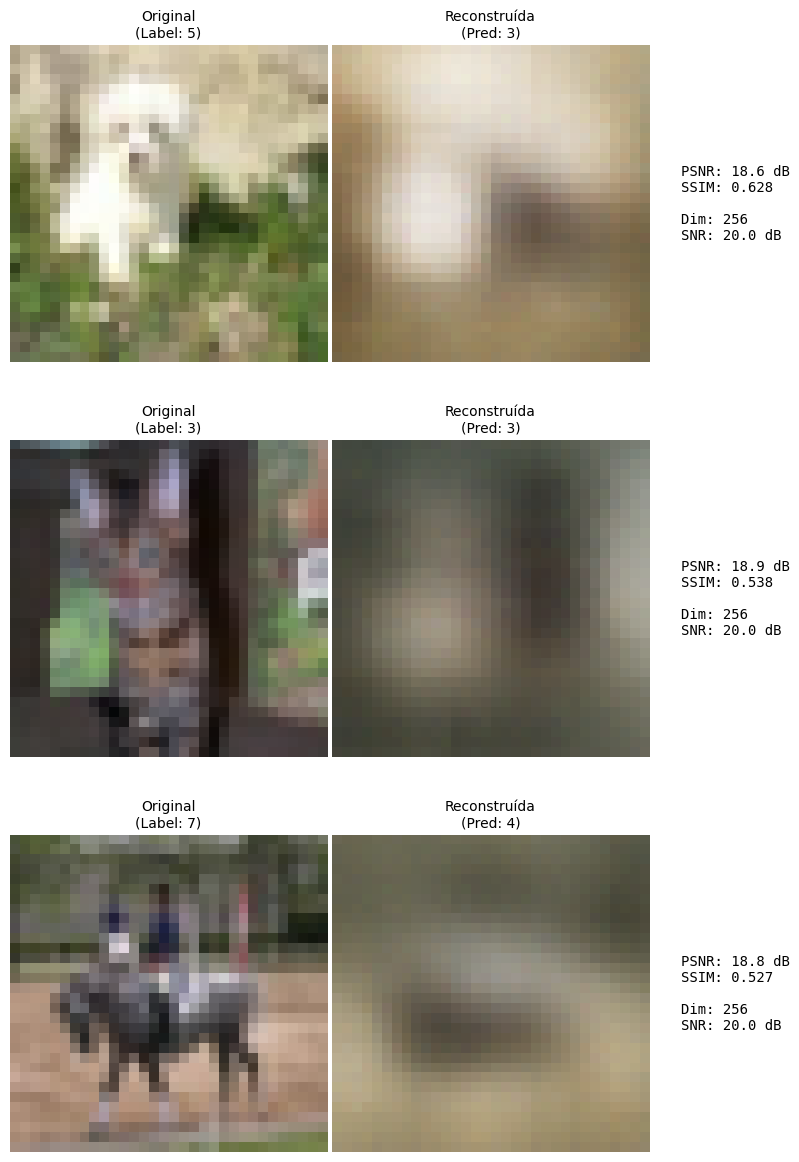

In [26]:
# Célula 6: Mosaico Visual (CÓDIGO CORRIGIDO DEFINITIVO)
import requests
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def load_image_from_response(img_data):
    if not img_data:
        return None
    
    # O backend envia uma matriz de pixels [C, H, W] (ex: 3x32x32) com valores entre 0 e 1
    arr = np.array(img_data)
    
    # Se for CHW, converte para HWC (formato que o matplotlib e PIL gostam)
    if arr.ndim == 3 and arr.shape[0] in [1, 3]:
        arr = np.transpose(arr, (1, 2, 0))
    if arr.ndim == 3 and arr.shape[2] == 1:
        arr = arr.squeeze(-1) # Grayscale
        
    # Escalar de [0, 1] para [0, 255] para virar uma imagem de verdade
    arr = (arr * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def generate_mosaic():
    URL = "http://localhost:8000/experiment/benchmark"
    payload = {
        "datasets": ["cifar10"],
        "models": ["cnn_vae"],
        "num_samples": 3,
        "latent_dim": 256,
        "compression_bits": 8,
        "include_samples": True,
        "awgn": {"enabled": True, "snr_db": 20.0},
        "masking": {"enabled": False, "drop_rate": 0.05, "fill_value": 0.0},
        "classifier": {"enabled": True}
    }
    
    response = requests.post(URL, json=payload)
    if response.status_code != 200:
        print("Erro na API:", response.text)
        return
    
    payload_resp = response.json()
    if "results" not in payload_resp:
        print("Resposta inesperada:", payload_resp)
        return
        
    results = payload_resp["results"]
    if not results:
        print("A lista de resultados veio vazia.")
        return
    
    data = results[0]
    samples = data.get("classification", {}).get("samples", [])
    
    if not samples:
        print("Nenhuma amostra visual retornada. Verifique se include_samples=True e o classifier está ativado.")
        return
    
    fig, axes = plt.subplots(len(samples), 2, figsize=(8, 4 * len(samples)))
    if len(samples) == 1:
        axes = [axes]
    
    fig.patch.set_facecolor('white')
    
    for i, sample in enumerate(samples):
        orig_img = load_image_from_response(sample.get("original_img"))
        recon_img = load_image_from_response(sample.get("reconstructed_img"))
        
        gt_label = sample.get("label", "Desconhecido")
        
        cls_info_recon = sample.get("reconstructed", {})
        recon_pred = cls_info_recon.get("pred", "sem juiz")
        
        # Configurar Original
        axes[i][0].imshow(orig_img)
        axes[i][0].set_title(f"Original\n(Label: {gt_label})", fontsize=10)
        axes[i][0].axis("off")
        
        # Configurar Reconstruída
        axes[i][1].imshow(recon_img)
        axes[i][1].set_title(f"Reconstruída\n(Pred: {recon_pred})", fontsize=10)
        axes[i][1].axis("off")
        
        # Adicionar métricas ao lado da reconstruída
        metrics_text = (
            f"PSNR: {sample.get('psnr', 0):.1f} dB\n"
            f"SSIM: {sample.get('ssim', 0):.3f}\n\n"
            f"Dim: {payload['latent_dim']}\n"
            f"SNR: {payload['awgn']['snr_db']} dB"
        )
        axes[i][1].text(
            1.1, 0.5, metrics_text,
            transform=axes[i][1].transAxes,
            fontsize=10,
            verticalalignment='center',
            family='monospace'
        )

    plt.tight_layout()
    plt.show()

generate_mosaic()


---
## 🏭 Módulo 4: A Fábrica de Trabalhos (Triple Trade-off)

O Evento Principal. Estressando as taxas de compactação a níveis drásticos para exportar pontuações de Acurácia x Compressão para o Manuscripto Final acadêmico.


Testando latent_dim = 16...
  acc=0.000  psnr=12.2 dB  bw_red=99.8%
Testando latent_dim = 32...
  acc=0.180  psnr=18.4 dB  bw_red=99.7%
Testando latent_dim = 64...
  acc=0.000  psnr=13.4 dB  bw_red=99.4%
Testando latent_dim = 128...
  acc=0.000  psnr=12.4 dB  bw_red=98.9%
Testando latent_dim = 256...
  acc=0.160  psnr=18.3 dB  bw_red=97.9%


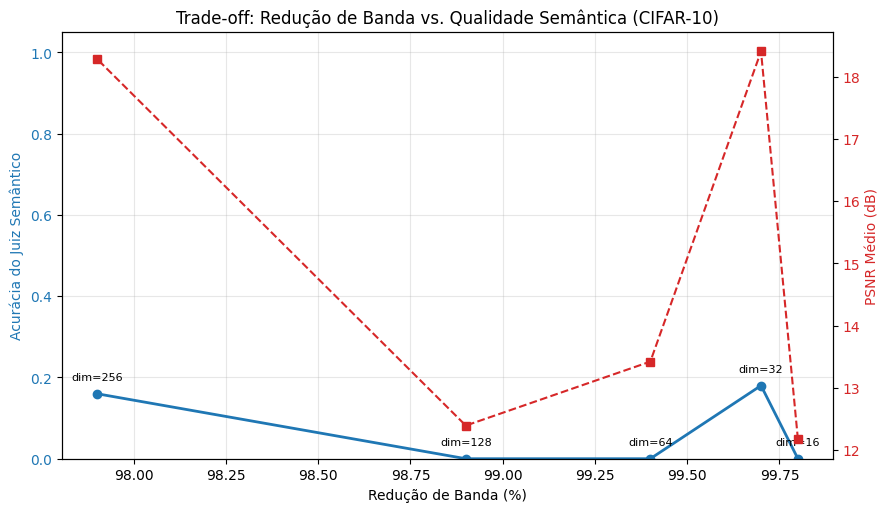

In [24]:
# Célula 7: Benchmark Trade-off Curve
import requests
import matplotlib.pyplot as plt
import numpy as np

def run_benchmark():
    URL = "http://localhost:8000/experiment/benchmark"
    latent_dims = [16, 32, 64, 128, 256]
    
    results_acc = []
    results_psnr = []
    bandwidth_reduction = []
    
    for dim in latent_dims:
        payload = {
            "datasets": ["cifar10"],       # ← lista, não string
            "models": ["cnn_vae"],
            "latent_dim": dim,
            "num_samples": 50,
            "compression_bits": 8,
            "awgn": {"enabled": True, "snr_db": 10.0},
            "masking": {"enabled": False, "drop_rate": 0.05, "fill_value": 0.0},
            "classifier": {"enabled": True}
        }
        
        print(f"Testando latent_dim = {dim}...")
        resp = requests.post(URL, json=payload)
        if resp.status_code == 200:
            results = resp.json().get("results", [])  # ← chave correta
            if not results:
                print(f"  Sem resultados para dim={dim}")
                continue
            
            data = results[0]
            acc_recon = data.get("classification", {}).get("accuracy_reconstructed", 0.0) or 0.0
            results_acc.append(acc_recon)
            results_psnr.append(data.get("psnr_mean", 0.0))
            bandwidth_reduction.append(data.get("bandwidth_reduction_pct", 0.0))
            print(f"  acc={acc_recon:.3f}  psnr={data.get('psnr_mean',0):.1f} dB  bw_red={data.get('bandwidth_reduction_pct',0):.1f}%")
        else:
            print(f"  Erro {resp.status_code}: {resp.text[:200]}")

    if not results_acc:
        print("Nenhum resultado coletado.")
        return

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.set_xlabel("Redução de Banda (%)")
    
    color = "tab:blue"
    ax1.set_ylabel("Acurácia do Juiz Semântico", color=color)
    ax1.plot(bandwidth_reduction, results_acc, marker='o', color=color, linewidth=2, label="Acurácia Reconstruída")
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()
    color = "tab:red"
    ax2.set_ylabel("PSNR Médio (dB)", color=color)
    ax2.plot(bandwidth_reduction, results_psnr, marker='s', color=color, linestyle='--', label="PSNR")
    ax2.tick_params(axis='y', labelcolor=color)
    
    for i, txt in enumerate(latent_dims[:len(bandwidth_reduction)]):
        ax1.annotate(f"dim={txt}", (bandwidth_reduction[i], results_acc[i]),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

    fig.tight_layout()
    plt.title("Trade-off: Redução de Banda vs. Qualidade Semântica (CIFAR-10)")
    plt.show()

run_benchmark()
